In [6]:
import pandas as pd

df = pd.read_pickle('../data-reeval-multi/calibration_results_lada_joint.pkl')

# Load IRT baseline from MIRT calibration results
df_mirt = pd.read_pickle('../data-reeval-multi/calibration_results.pkl')
# Get unique IRT values per scenario (they're the same across k-factors in MIRT)
df_irt = df_mirt.groupby('scenario')[['irt']].first().reset_index()

# Merge IRT baseline into LADA data
df = df.merge(df_irt, on='scenario', how='left')

In [7]:
# Check the dataframe structure
print("DataFrame shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst few rows:")
print(df.head())
print("\nScenarios with missing size:")
print(df[df['size'].isna()]['scenario'].unique())

DataFrame shape: (69, 9)

Columns: ['scenario', 'k_factor', 'test_auc', 'aic', 'bic', 'best_epoch', 'log_likelihood', 'size', 'irt']

First few rows:
                 scenario  k_factor  test_auc            aic            bic  \
0  entity_data_imputation         2  0.968439   11419.750977   23766.385403   
1                    imdb         2  0.941862   76252.800781  184368.705943   
2         entity_matching         2  0.940301   47882.695312   89883.876167   
3             commonsense         2  0.924221   22631.257812   38438.156415   
4          air_bench_2024         2  0.910455  145096.507812  298377.247900   

   best_epoch  log_likelihood    size       irt  
0         118    -4158.875488   395.0  0.934480  
1          58   -27170.400391  3530.0  0.882950  
2          63   -19387.347656  1396.0  0.886959  
3          92    -9455.628906   498.0  0.920394  
4          43   -57227.253906  4985.0  0.903832  

Scenarios with missing size:
['combined_data']


/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_57598/1322328949.py:82: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


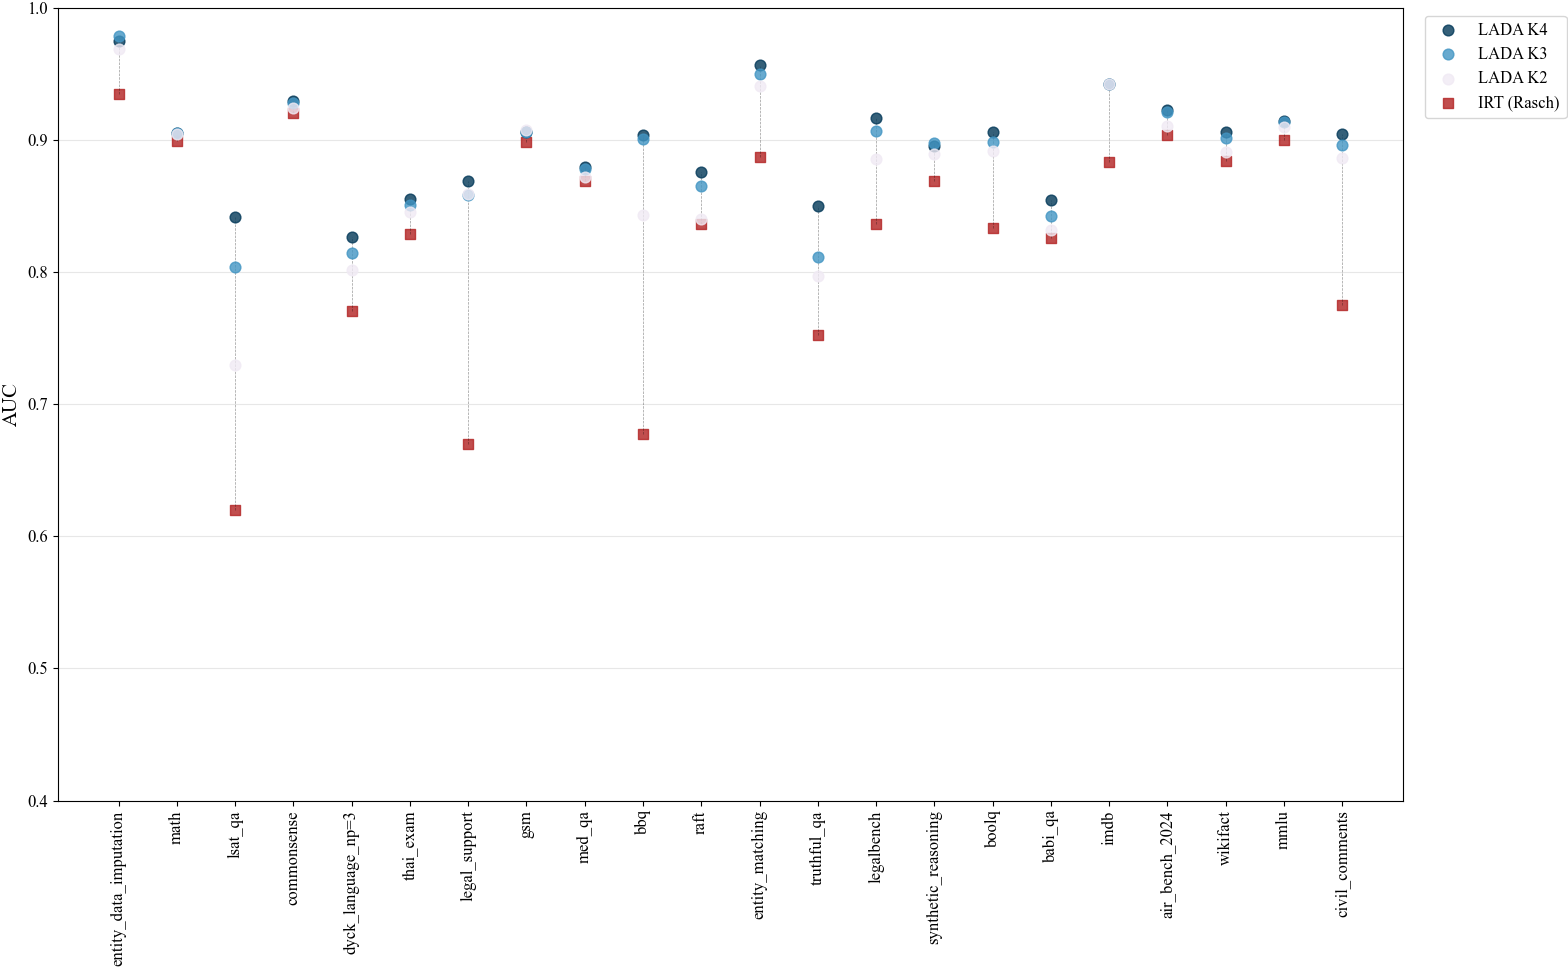

In [ ]:
import matplotlib.pyplot as plt
import sys
sys.path.append('..') 
import style

# Filter out rows with missing size values
df_plot = df.dropna(subset=['size']).copy()

# Create the transposed dumbbell plot with k-factor colors, sorted by scenario size
fig, ax = plt.subplots(figsize=(16, 10))

# Get unique scenarios and k-factors, sort scenarios by size
scenario_size_mapping = df_plot.groupby('scenario')['size'].first().to_dict()
# Convert sizes to int for cleaner display
scenario_size_mapping = {k: int(v) for k, v in scenario_size_mapping.items()}
scenarios = sorted(df_plot['scenario'].unique(), key=lambda x: scenario_size_mapping[x])
k_factors = sorted(df_plot['k_factor'].unique())

# Create a grayscale colormap that reflects numerical order
colors = plt.get_cmap('PuBu')
# Use a subset of the colormap to avoid too light colors
color_map = {k: colors(0.1 + 1 * (i / max(1, len(k_factors) - 1))) for i, k in enumerate(k_factors)}

# Create x positions for each scenario (now ordered by size)
x_pos = {scenario: i for i, scenario in enumerate(scenarios)}

# Plot for each k-factor
for k_factor in reversed(k_factors):
	df_k = df_plot[df_plot['k_factor'] == k_factor]
	
	if len(df_k) == 0:
		continue
	
	# Get x positions for this k-factor's scenarios
	x_positions = [x_pos[scenario] for scenario in df_k['scenario']]
	
	# Plot the LADA points
	ax.scatter(x_positions, df_k['test_auc'], 
			  color=color_map[k_factor], s=60, 
			  label=f'LADA K{k_factor}', 
			  marker='o', alpha=0.8, zorder=3)

# Plot IRT (Rasch) points - same for all k-factors
# Get one representative IRT value per scenario
df_irt = df_plot.groupby('scenario')[['irt', 'size']].first().reset_index()
df_irt = df_irt.set_index('scenario').loc[scenarios].reset_index()  # Ensure same ordering
x_positions_irt = [x_pos[scenario] for scenario in df_irt['scenario']]

ax.scatter(x_positions_irt, df_irt['irt'], 
          color='firebrick', s=60, 
          label='IRT (Rasch)', 
          marker='s', alpha=0.8, zorder=2)

# Plot connecting lines between lowest and highest values for each scenario
for scenario in scenarios:
	df_scenario = df_plot[df_plot['scenario'] == scenario]
	if len(df_scenario) == 0:
		continue
	
	x = x_pos[scenario]
	
	# Get all values (both IRT and LADA) for this scenario
	all_values = list(df_scenario['test_auc']) + [df_scenario['irt'].iloc[0]]
	
	# Find min and max values
	min_val = min(all_values)
	max_val = max(all_values)
	
	# Draw line from lowest to highest value
	ax.plot([x, x], [min_val, max_val], 'k--', linewidth=0.5, alpha=0.4)

# Customize the plot
ax.set_xticks(range(len(scenarios)))
# Create labels with both scenario name and size
scenario_labels = [f"{scenario}" for scenario in scenarios]
ax.set_xticklabels(scenario_labels, rotation=90)
ax.set_ylabel('AUC')
ax.set_ylim(0.4, 1.0)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_57598/723465619.py:102: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


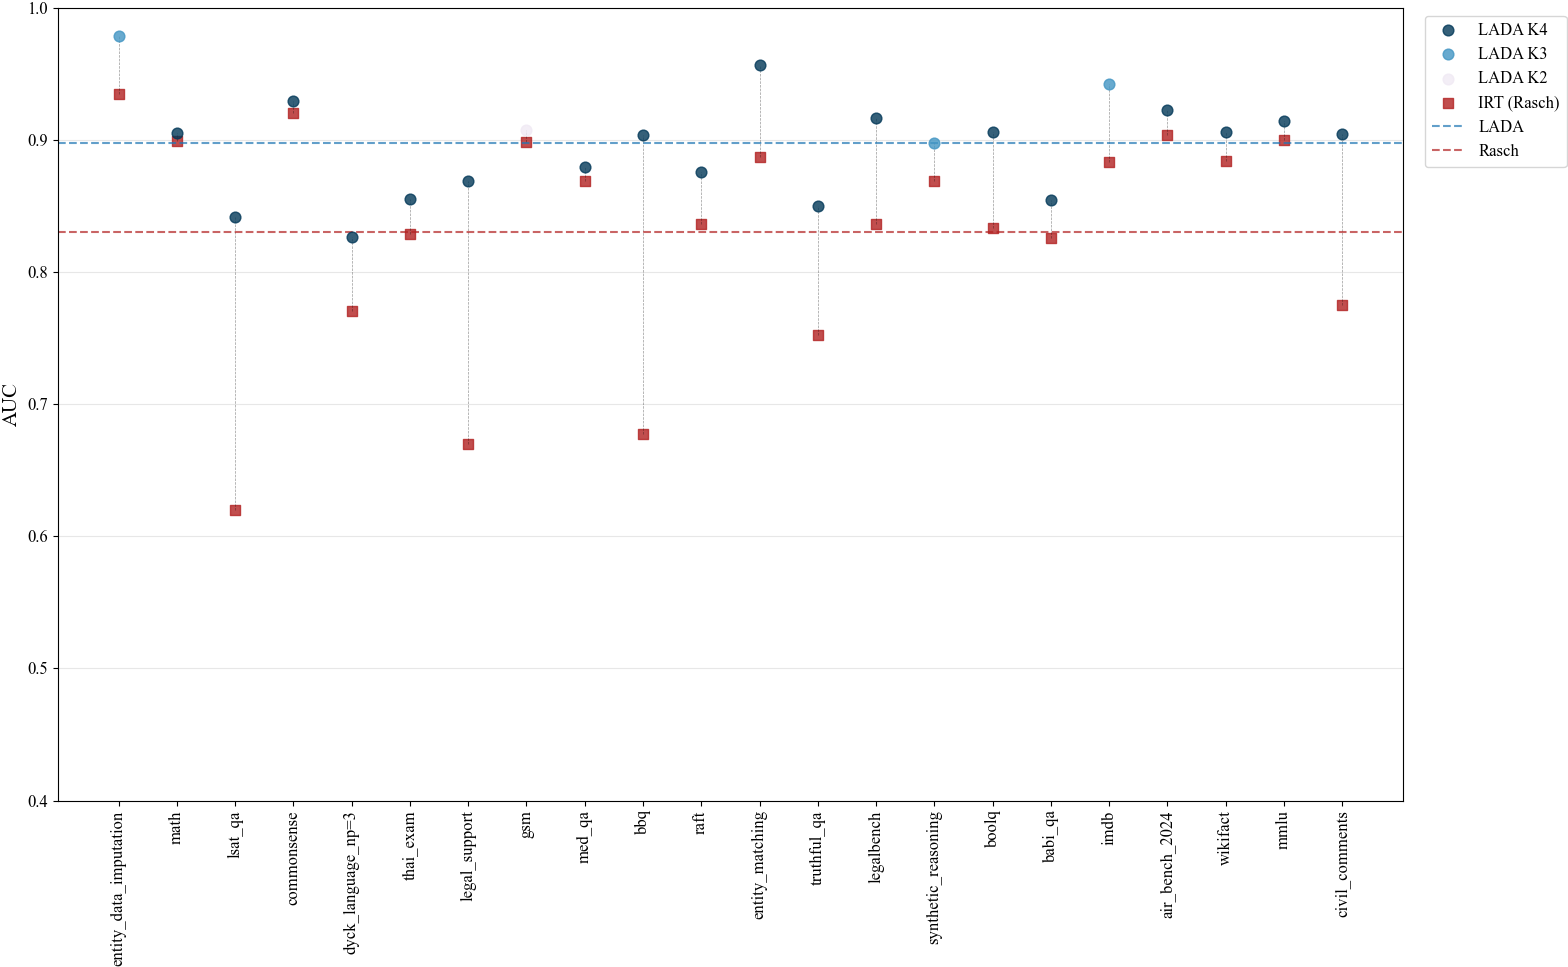

In [9]:
import matplotlib.pyplot as plt
import sys
sys.path.append('..') 
import style

# Filter out rows with missing size values
df_plot = df.dropna(subset=['size']).copy()

# Create the transposed dumbbell plot with k-factor colors, sorted by scenario size
fig, ax = plt.subplots(figsize=(16, 10))

# Get unique scenarios and k-factors, sort scenarios by size
scenario_size_mapping = df_plot.groupby('scenario')['size'].first().to_dict()
# Convert sizes to int for cleaner display
scenario_size_mapping = {k: int(v) for k, v in scenario_size_mapping.items()}
scenarios = sorted(df_plot['scenario'].unique(), key=lambda x: scenario_size_mapping[x])
k_factors = sorted(df_plot['k_factor'].unique())

# Create a grayscale colormap that reflects numerical order
colors = plt.get_cmap('PuBu')
# Use a subset of the colormap to avoid too light colors
color_map = {k: colors(0.1 + 1 * (i / max(1, len(k_factors) - 1))) for i, k in enumerate(k_factors)}

# Create x positions for each scenario (now ordered by size)
x_pos = {scenario: i for i, scenario in enumerate(scenarios)}

# For each scenario, find the highest LADA AUC across all k-factors
highest_lada_data = []
for scenario in scenarios:
    df_scenario = df_plot[df_plot['scenario'] == scenario]
    if len(df_scenario) > 0:
        # Find the row with the highest LADA AUC for this scenario
        max_lada_row = df_scenario.loc[df_scenario['test_auc'].idxmax()]
        highest_lada_data.append({
            'scenario': scenario,
            'test_auc': max_lada_row['test_auc'],
            'k_factor': max_lada_row['k_factor'],
            'irt': max_lada_row['irt'],
            'size': max_lada_row['size']
        })

# Convert to DataFrame for easier handling
highest_lada_df = pd.DataFrame(highest_lada_data)

# Get unique k-factors that actually appear as highest performers
highest_k_factors = sorted(highest_lada_df['k_factor'].unique())

# Plot the highest LADA points grouped by k-factor for legend purposes
plotted_k_factors = set()
for k_factor in reversed(highest_k_factors):
    # Get all scenarios where this k-factor is the highest performer
    k_data = highest_lada_df[highest_lada_df['k_factor'] == k_factor]
    
    x_positions = [x_pos[scenario] for scenario in k_data['scenario']]
    
    # Plot points for this k-factor
    ax.scatter(x_positions, k_data['test_auc'], 
              color=color_map[k_factor], s=60, 
              label=f'LADA K{k_factor}', 
              marker='o', alpha=0.8, zorder=3)
    
    plotted_k_factors.add(k_factor)

# Plot IRT (Rasch) points - same for all k-factors
# Get one representative IRT value per scenario
df_irt = df_plot.groupby('scenario')[['irt', 'size']].first().reset_index()
df_irt = df_irt.set_index('scenario').loc[scenarios].reset_index()  # Ensure same ordering
x_positions_irt = [x_pos[scenario] for scenario in df_irt['scenario']]

ax.scatter(x_positions_irt, df_irt['irt'], 
          color='firebrick', s=60, 
          label='IRT (Rasch)', 
          marker='s', alpha=0.8, zorder=2)

# Plot connecting lines between IRT and highest LADA for each scenario
for _, row in highest_lada_df.iterrows():
    x = x_pos[row['scenario']]
    
    # Draw line between IRT and highest LADA value
    ax.plot([x, x], [row['irt'], row['test_auc']], 'k--', linewidth=0.5, alpha=0.4)

# Calculate and plot average lines
lada_avg = highest_lada_df['test_auc'].mean()
irt_avg = df_irt['irt'].mean()

# Add horizontal lines for averages
ax.axhline(y=lada_avg, color='C0', linestyle='--', linewidth=1.5, alpha=0.7, 
           label=f'LADA', zorder=2)
ax.axhline(y=irt_avg, color='firebrick', linestyle='--', linewidth=1.5, alpha=0.7, 
           label=f'Rasch', zorder=2)

# Customize the plot
ax.set_xticks(range(len(scenarios)))
# Create labels with both scenario name and size
scenario_labels = [f"{scenario}" for scenario in scenarios]
ax.set_xticklabels(scenario_labels, rotation=90)
ax.set_ylabel('AUC')
ax.set_ylim(0.4, 1.0)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()